AI Assistance: OpenAI ChatGPT and Anthropic's Claude were used for code debugging, code generation, code organization, and code methodological brainstorming\. All final modeling, implementation, validation, commentary, and interpretation were performed and verified by the authors\.

In [1]:
import pandas as pd
import duckdb
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path

platform = 'deepnote'

if platform == 'deepnote':
    PROCESSED_DIR = Path('data/Processed')
if platform == 'vscode':
    PROCESSED_DIR = Path('work/Processed')

# I\. Load train, validation, and test sets

In [3]:
df_train = pd.read_parquet(PROCESSED_DIR / 'omni_train_cleaned.parquet')
df_validation = pd.read_parquet(PROCESSED_DIR / 'omni_validation_cleaned.parquet')
df_test = pd.read_parquet(PROCESSED_DIR / 'omni_test_cleaned.parquet')

original_train_count = len(df_train)
original_validation_count = len(df_validation)
original_test_count = len(df_test)

# II. Concatenate train/validation/test for log transforms

In [5]:
df_concat = pd.concat([df_train, df_validation, df_test], ignore_index=True)
df_concat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13654494 entries, 0 to 13654493
Data columns (total 19 columns):
 #   Column               Dtype         
---  ------               -----         
 0   datetime             datetime64[us]
 1   year                 int64         
 2   day                  int64         
 3   hour                 int64         
 4   minute               int64         
 5   mag_avg_nt           float64       
 6   bx_gsm_nt            float64       
 7   by_gsm_nt            float64       
 8   bz_gsm_nt            float64       
 9   flow_speed_km_s      float64       
 10  proton_density_n_cc  float64       
 11  day_cos              float64       
 12  day_sin              float64       
 13  hour_cos             float64       
 14  hour_sin             float64       
 15  minute_cos           float64       
 16  minute_sin           float64       
 17  kp_10                int64         
 18  data_split           object        
dtypes: datetime64[us](1

In [ ]:
# Validation
concat_train_count = len(df_concat[df_concat['data_split'] == 'train'])
concat_validation_count = len(df_concat[df_concat['data_split'] == 'validation'])
concat_test_count = len(df_concat[df_concat['data_split'] == 'test'])

assert len(df_concat) == original_train_count + original_validation_count + original_test_count
assert concat_train_count == original_train_count
assert concat_validation_count == original_validation_count
assert concat_test_count == original_test_count

In [15]:
def compute_skewness(df, columns, threshold=0.8):
    """Reports Fisher-Pearson skewness for the given column(s) and flags any exceeding threshold."""
    if isinstance(columns, str):
        columns = [columns]

    results = []
    for col in columns:
        skew_value = df[col].skew()
        exceeds_threshold = abs(skew_value) > threshold
        results.append({'column': col, 'skew': skew_value, 'exceeds_threshold': exceeds_threshold})
        flag = ' <-- exceeds threshold' if exceeds_threshold else ''
        print(f'{col}: skew={skew_value:.4f}{flag}')

    return pd.DataFrame(results)

In [16]:
col_list = ['mag_avg_nt', 'flow_speed_km_s', 'proton_density_n_cc']

df_skew = compute_skewness(df=df_concat, columns=col_list, threshold=0.8)

mag_avg_nt: skew=2.9193 <-- exceeds threshold
flow_speed_km_s: skew=0.9986 <-- exceeds threshold
proton_density_n_cc: skew=3.3371 <-- exceeds threshold


,column,skew,exceeds_threshold
0,mag_avg_nt,2.919300,True
1,flow_speed_km_s,0.998589,True
2,proton_density_n_cc,3.337055,True


In [17]:
def add_log_transformed_columns(df, columns):
    """Adds log1p-transformed copies of the given column(s) as new '<col>_log' columns."""
    df = df.copy()
    if isinstance(columns, str):
        columns = [columns]

    for col in columns:
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            print(f'Warning: {col} has {negative_count:,} negative values; log1p will produce NaN for these.')
        df[f'{col}_log'] = np.log1p(df[col])
        print(f'Added {col}_log — min={df[f"{col}_log"].min():.4f}, max={df[f"{col}_log"].max():.4f}, '
              f'NaNs={df[f"{col}_log"].isna().sum():,}')

    return df

In [18]:
col_list = ['mag_avg_nt', 'flow_speed_km_s', 'proton_density_n_cc']

df_log = add_log_transformed_columns(df=df_concat, columns=col_list)

Added mag_avg_nt_log — min=0.1222, max=4.3028, NaNs=0
Added flow_speed_km_s_log — min=5.4446, max=6.9939, NaNs=0
Added proton_density_n_cc_log — min=0.0296, max=4.4061, NaNs=0


,datetime,year,day,hour,minute,mag_avg_nt,bx_gsm_nt,by_gsm_nt,bz_gsm_nt,flow_speed_km_s,...,day_sin,hour_cos,hour_sin,minute_cos,minute_sin,kp_10,data_split,mag_avg_nt_log,flow_speed_km_s_log,proton_density_n_cc_log
0,2000-01-01 00:00:00,2000,1,0,0,6.820,-5.940,0.27,-0.08,664.7,...,0.017213,1.0,0.0,1.000000,0.000000,53,train,2.056685,6.500839,1.415853
1,2000-01-01 00:01:00,2000,1,0,1,6.990,-5.880,1.95,1.08,664.7,...,0.017213,1.0,0.0,0.994522,0.104528,53,train,2.078191,6.500839,1.415853
2,2000-01-01 00:02:00,2000,1,0,2,6.990,-5.710,2.74,2.24,663.2,...,0.017213,1.0,0.0,0.978148,0.207912,53,train,2.078191,6.498583,1.444563
3,2000-01-01 00:03:00,2000,1,0,3,6.830,-5.330,3.18,2.78,662.2,...,0.017213,1.0,0.0,0.951057,0.309017,53,train,2.057963,6.497077,1.413423
4,2000-01-01 00:04:00,2000,1,0,4,6.905,-4.565,2.99,3.76,675.3,...,0.017213,1.0,0.0,0.913545,0.406737,53,train,2.067495,6.516637,1.342865


In [21]:
import matplotlib.pyplot as plt

def plot_histogram(df, column, bins=50):
    """Plots a histogram for the given column and prints summary stats."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df[column].dropna(), bins=bins, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    plt.show()

    print(f'{column}: n={df[column].notna().sum():,}, mean={df[column].mean():.4f}, '
          f'std={df[column].std():.4f}, skew={df[column].skew():.4f}')

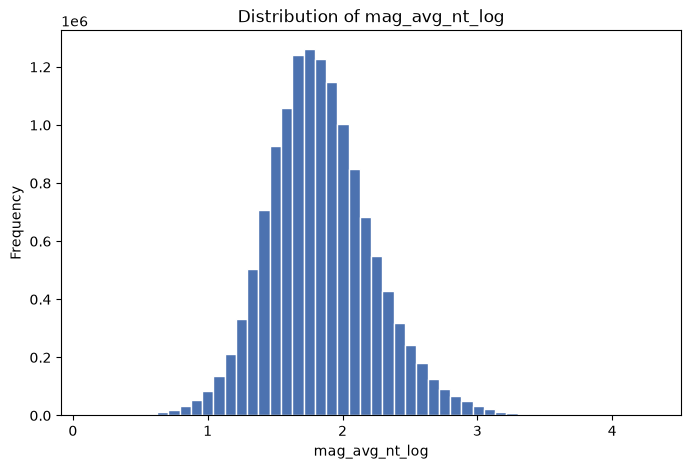

mag_avg_nt_log: n=13,654,494, mean=1.8367, std=0.3927, skew=0.4093


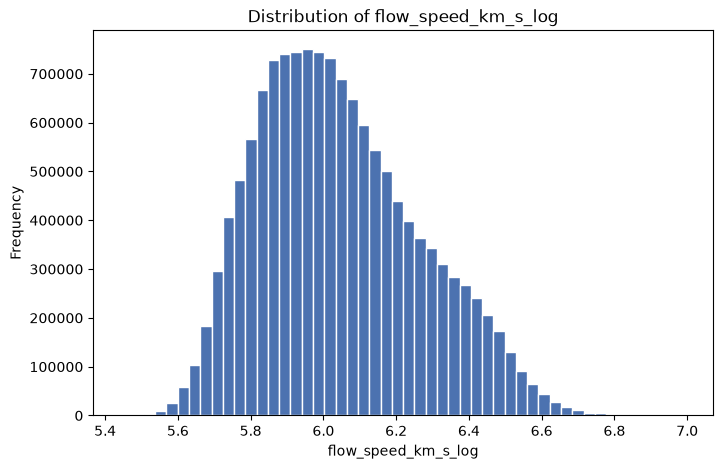

flow_speed_km_s_log: n=13,654,494, mean=6.0431, std=0.2227, skew=0.4673


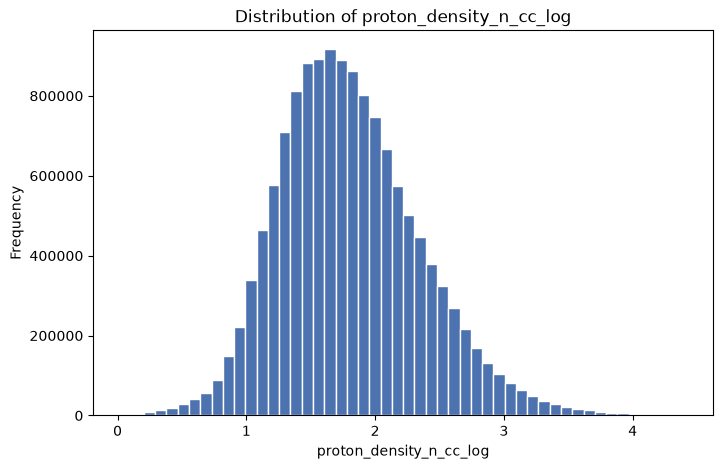

proton_density_n_cc_log: n=13,654,494, mean=1.8031, std=0.5484, skew=0.4966


In [22]:
log_col_list = ['mag_avg_nt_log', 'flow_speed_km_s_log', 'proton_density_n_cc_log']

for col in log_col_list:
    plot_histogram(df=df_log, column=col, bins=50)

In [23]:
# Re-split the data into train/validation/test and validate the df lengths
df_train_log = df_log[df_log['data_split'] == 'train']
df_validation_log = df_log[df_log['data_split'] == 'validation']
df_test_log = df_log[df_log['data_split'] == 'test']

assert len(df_train_log) == len(df_train)
assert len(df_validation_log) == len(df_validation)
assert len(df_test_log) == len(df_test)

# VI\. Final export to parquet

In [25]:
# # Write datasets to parquet with the log transforms
train_output_path = PROCESSED_DIR / 'omni_train_cleaned_log.parquet'
validation_output_path = PROCESSED_DIR / 'omni_validation_cleaned_log.parquet'
test_output_path = PROCESSED_DIR / 'omni_test_cleaned_log.parquet'

df_train_log.to_parquet(train_output_path)
df_validation_log.to_parquet(validation_output_path)
df_test_log.to_parquet(test_output_path)

print(f'Wrote {len(df_train_log):,} rows to {train_output_path.as_posix()}')
print(f'Wrote {len(df_validation_log):,} rows to {validation_output_path.as_posix()}')
print(f'Wrote {len(df_test_log):,} rows to {test_output_path.as_posix()}')

Wrote 10,334,497 rows to work/Processed/omni_train_cleaned_log.parquet
Wrote 1,800,962 rows to work/Processed/omni_validation_cleaned_log.parquet
Wrote 1,519,035 rows to work/Processed/omni_test_cleaned_log.parquet


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a18bf7d-431c-4909-af8a-a54a62228a78' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>